# Unified HDF5 Verification (Step 8.2)

Visual checks on the converted unified HDF5:
1. Camera slots — cam_0 front, cam_3 wrist, cam_1/2 black
2. 7D action trajectory — smooth curves, clear gripper open/close

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

HDF5_PATH = "c:/Users/naqee/OneDrive/Desktop/CSC415 Project/data/unified/robomimic/lift/ph.hdf5"
ACTION_LABELS = ["Δx", "Δy", "Δz", "Δrx", "Δry", "Δrz", "gripper"]

## 1. Camera Slots — First Frame of demo_0

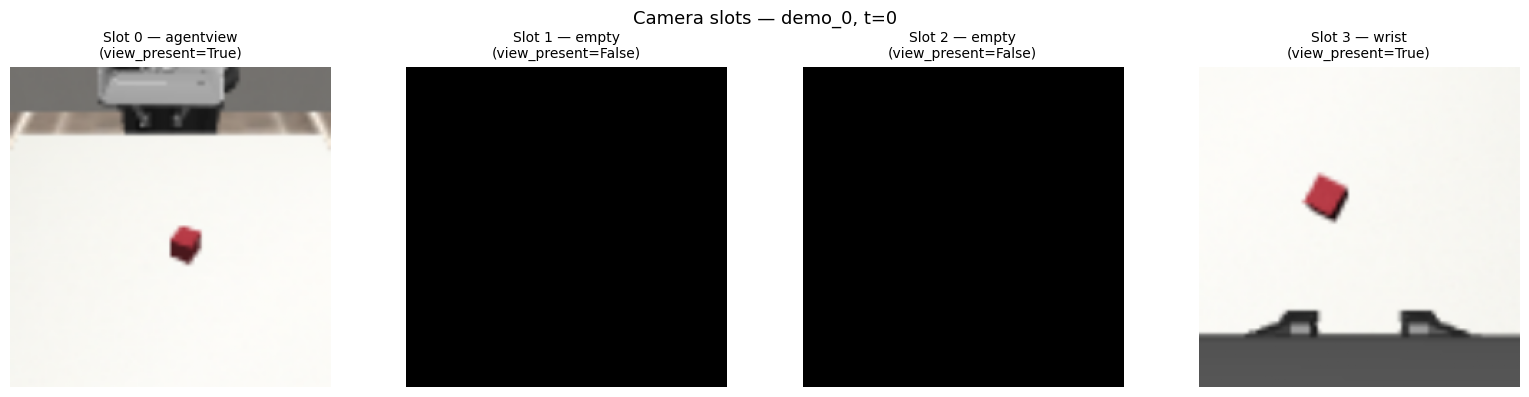

Image pixel range: [0.000, 0.996]


In [2]:
with h5py.File(HDF5_PATH, "r") as f:
    demo_key = list(f["data"].keys())[0]
    first_frame = f[f"data/{demo_key}/images"][0]   # (4, 224, 224, 3) float32
    view_present = f[f"data/{demo_key}/view_present"][:]  # (4,) bool

slot_labels = [
    f"Slot 0 — agentview\n(view_present={view_present[0]})",
    f"Slot 1 — empty\n(view_present={view_present[1]})",
    f"Slot 2 — empty\n(view_present={view_present[2]})",
    f"Slot 3 — wrist\n(view_present={view_present[3]})",
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    ax.imshow(first_frame[i])   # float32 [0,1] renders directly
    ax.set_title(slot_labels[i], fontsize=10)
    ax.axis("off")
plt.suptitle(f"Camera slots — {demo_key}, t=0", fontsize=13)
plt.tight_layout()
plt.savefig("camera_slots_unified.png", dpi=100)
plt.show()
print(f"Image pixel range: [{first_frame.min():.3f}, {first_frame.max():.3f}]")

## 2. Action Trajectory — demo_0

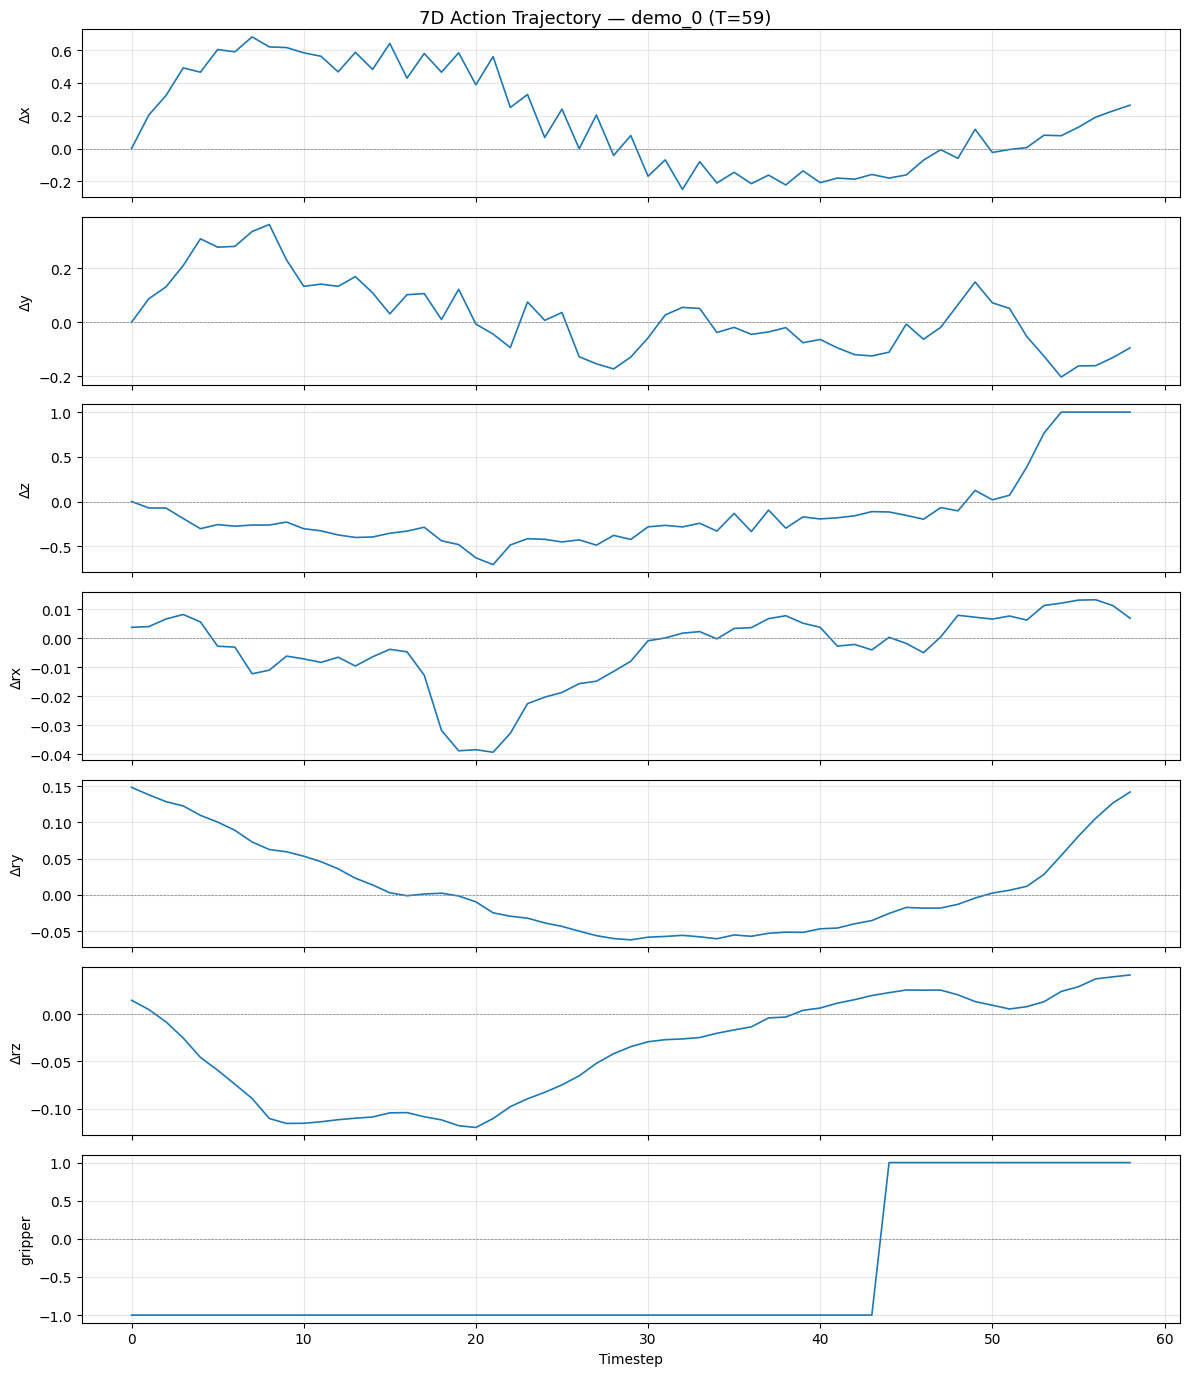

Action shape: (59, 7)
Gripper range: [-1.000, 1.000]


In [3]:
with h5py.File(HDF5_PATH, "r") as f:
    demo_key = list(f["data"].keys())[0]
    actions = f[f"data/{demo_key}/actions"][:]  # (T, 7)

T = actions.shape[0]
t = np.arange(T)

fig, axes = plt.subplots(7, 1, figsize=(12, 14), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, actions[:, i], linewidth=1.2)
    ax.set_ylabel(ACTION_LABELS[i], fontsize=10)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Timestep")
plt.suptitle(f"7D Action Trajectory — {demo_key} (T={T})", fontsize=13)
plt.tight_layout()
plt.savefig("action_trajectory_unified.png", dpi=100)
plt.show()
print(f"Action shape: {actions.shape}")
print(f"Gripper range: [{actions[:, 6].min():.3f}, {actions[:, 6].max():.3f}]")

## 3. Norm Stats Summary

In [4]:
import sys
sys.path.insert(0, "c:/Users/naqee/OneDrive/Desktop/CSC415 Project/RAEDiTRobotics")
from data_pipeline.conversion.compute_norm_stats import load_norm_stats

stats = load_norm_stats(HDF5_PATH)
print("Action mean:", np.round(stats["actions"]["mean"], 4))
print("Action std: ", np.round(stats["actions"]["std"],  4))
print("Proprio mean:", np.round(stats["proprio"]["mean"], 4))
print("Proprio std: ", np.round(stats["proprio"]["std"],  4))

Action mean: [ 0.1735  0.0064 -0.1699  0.0033  0.0054  0.0135 -0.4056]
Action std:  [0.2603 0.1307 0.4963 0.0224 0.0631 0.0854 0.9141]
Proprio mean: [-2.250e-02 -1.800e-03  8.930e-01  9.911e-01  1.720e-02  4.930e-02
 -7.000e-04  3.380e-02 -3.400e-02]
Proprio std:  [0.0406 0.0156 0.0651 0.0099 0.1177 0.028  0.0157 0.0076 0.0072]
